# Üç Model için Grad-CAM Karşılaştırması (YOLO11s, YOLO26s, RF-DETR-S)

Bu notebook, projedeki üç modelin (en iyi/final ayarlarıyla eğitilmiş) test seti
üzerinde Grad-CAM ısı haritalarını tek bir yerde, tutarlı bir görsel stille üretir.

## Yöntem -- literatür özeti

**YOLO11 / YOLO26 (CNN tabanlı):** Kirchknopf vd. (2022), *"Explaining YOLO:
Leveraging Grad-CAM to Explain Object Detections"* makalesindeki yönteme
dayanıyor: belirli bir tespitin (kutunun) sınıf/objectness skorunu üreten
çıktı nöronu belirlenir (YOLO'da NMS tersine çevrilerek), bu skordan
modelin son evrişimli özellik haritasına (feature map) doğru gradyan geri
yayılır, gradyanlar o haritayı ağırlıklandırır ve girdi boyutuna
büyütülür. Bu, orijinal Grad-CAM makalesinin (Selvaraju vd., 2017)
YOLO'ya uyarlanmış hâli.

**RF-DETR (transformer/DETR tabanlı):** DETR-ailesi dedektörler için
literatürde iki ana yaklaşım var: (1) çapraz-dikkat (cross-attention)
ağırlıklarını doğrudan görselleştirmek (orijinal DETR makalesinin kendi
yöntemi), (2) omurga (backbone) özellik haritası üzerinde **gerçek
Grad-CAM** hesaplamak -- bu ikinci yaklaşım, dikkat haritalarını CNN
dedektörlerinin Grad-CAM'iyle karşılaştıran çalışmalarda "gerçek" Grad-CAM
referansı olarak kullanılıyor. Bu notebook ikinci yaklaşımı seçti: RF-DETR
kaynak kodu (github.com/roboflow/rf-detr, `develop` dalı) doğrudan
incelenerek omurganın döndürdüğü çok-ölçekli özellik haritaları (`Joiner.
forward`, `backbone[0]` = DINOv2+projektör) tespit edildi; sınıf logit'i
(`class_embed`, düz bir `Linear` katmanı, sorgu-başına) bu özellik
haritasına göre geri yayılıyor -- YOLO'dakiyle aynı temel Grad-CAM
formülü, sadece hedef katman transformer omurgasının çıktısı ve
normalizasyon adımı RF-DETR'ye özgü (aşağıda açıklanıyor).

**Doğrulandı:** RF-DETR mimarisi teşhis hücresinde birebir teyit edildi:
`pred_logits` `[1, 300, 2]`, `pred_boxes` `[1, 300, 4]`, `features[0].
tensors` `[1, 256, 32, 32]`.

## Görselleştirme -- karşılaşılan sorunlar ve nihai çözüm

**1) YOLO11/YOLO26 kenar/dolgu artefaktı (düzeltildi).** Konvolüsyonların
sıfır-dolgusundan kaynaklanan, içerikten bağımsız kenar sıcak noktası --
özellik haritasının en dış hücre halkası (~%4) sıfırlanarak, sabit eşik
yerine sürekli alfa-karışım kullanılarak giderildi.

**2) YOLO11/YOLO26'da harita hedef kutudan tamamen bağımsız, alakasız
yerlerde (meme ucu, deri kıvrımı, ilgisiz parlak dokular) izole "sıcak
nokta"lar üretiyordu; hedef kutunun içi genelde bomboş kalıyordu
(düzeltildi).**

- *Kök neden:* Kanal ağırlığı, gradyanın **tüm** özellik haritası
  üzerindeki global ortalaması (`w = G.mean(dim=[2,3])`, GAP) ile
  hesaplanıp, bu ağırlık **tüm** aktivasyon haritasına geri
  uygulanıyordu -- sınıflandırma-tarzı (görüntü-geneli tek skor)
  Grad-CAM için doğru, ama tekil bir tespit için yanlış: "hedefle
  alakalı" kanalın etiketi, o kanalın görüntüdeki BAŞKA (alakasız)
  konumlardaki aktivasyonuna da yayılıyordu.
- *Çözüm:* Gradyanı ortalamadan, eleman-bazlı **Grad × Aktivasyon**
  kullanılıyor: `cam = ReLU(sum_c G_c(x,y) * A_c(x,y))`. `G` zaten
  hedefe nedensel olarak bağlı olmayan bölgelerde sıfıra yakın olduğundan,
  bu çarpım uzamsal bilgiyi koruyup doğal olarak lokalize kalıyor.

**3) "Kaçırılan" (FN) örneklerde ısı haritası, düşük/eşik-altı bir
sinyali bile her görüntüde ayrı ayrı [0,1]'e normalize ettiği için,
"Doğru" (yüksek güvenli) örneklerle görsel olarak ayırt edilemez
hâle geliyordu -- gerçekte model o bölgeye çok zayıf bakmış olsa da
harita aynı yoğunlukta kırmızı çıkıyordu (düzeltildi).**

- *Çözüm:* Her panelin başlığına modelin gerçek güven skoru eklendi:
  tespit varsa (`conf>=0.25`) o skor; yoksa (kaçırılan durum) gerçek
  kutuya en çok örtüşen adayın eşik-altı skoru ("en yakın aday
  skor=0.11 (eşik altında)" gibi). Bu, düşük skorlu bir örnekte ısı
  haritasının yine de o bölgeye lokalize olabileceğini (backprop
  hedefi seçilen hücrenin reseptif alanı nedeniyle beklenen bir
  davranış) yanlış yorumlanmaya karşı netleştiriyor.

**4) RF-DETR'de standart ReLU-tabanlı Grad-CAM tamamen boş harita
üretiyordu -- kök neden DINOv2/ViT omurgasının LayerNorm istatistikleri,
üç adımda çözüldü:**
- *Teşhis:* `RF_DEBUG` çıktısı, yüksek güvenli tespitlerde ağırlıklı
  aktivasyon haritasının (ReLU öncesi) her yerde negatif çıktığını
  gösterdi -- ReLU bunu tamamen sıfırlıyordu.
- *1. deneme (ReLU'yu kaldırıp düz min-max normalize):* Boşluk sorunu
  çözüldü ama DINOv2'nin global self-attention'ından kaynaklanan yumuşak,
  geniş-ölçekli sinyal artık TÜM görüntüyü boyuyordu -- hiçbir bölge öne
  çıkmıyordu.
- *2. deneme (yüzdelik-dilim kırpma, %70-99):* Sadece en güçlü dilimi öne
  çıkarmayı denedi, ama kenar hücrelerini istatistik hesaplanmadan ÖNCE
  sıfırlamak, negatif-baskın görüntülerde yapay "0" değerinin en yüksek
  yüzdelik dilime girip haritayı yine boşaltmasına yol açtı.
- *Nihai çözüm:* Yüzdelik istatistiği (70.-99. yüzdelik) sadece kenar
  hariç **iç bölgeden** hesaplanıyor; kenar bastırma normalize ettikten
  **sonra** ayrı bir çarpımsal maske olarak uygulanıyor.

Teşhis çıktısını görmek isterseniz RF-DETR hücresindeki `RF_DEBUG = True`
yapıp tekrar çalıştırabilirsiniz.

**Not -- RF-DETR'nin yüzdelik-dilim kırpması YOLO'ya taşınmadı (denendi,
geri alındı).** Kök neden: YOLO'nun haritası ReLU'lu olduğundan çok
seyrek (aktif hücreler genelde haritanın %1'inden azı); böyle bir dizide
70.-99. yüzdelik neredeyse her zaman sıfır kütlesinin içine düşüp
`lo=hi=0` veriyor ve haritayı tamamen sıfırlıyor. RF-DETR'nin haritası ise
ReLU'suz, yoğun ve işaretli (negatif+pozitif) olduğundan aynı teknik orada
işe yarıyordu -- iki mimari aynı normalizasyon stratejisini paylaşamıyor.
Bu yüzden YOLO11/YOLO26 hücrelerinde basit kenar sıfırlama + düz min-max
korundu; RF-DETR hücresi yüzdelik-dilim yöntemini korudu.

## Kurulum

In [1]:
# atanan GPU kontrolu, T4 bekleniyor
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader


Tesla T4, 15360 MiB


In [2]:
# ultralytics (YOLO11/YOLO26) + rfdetr (RF-DETR) + goruntu/cizim kutuphaneleri
!pip install -q ultralytics rfdetr opencv-python-headless matplotlib


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from pathlib import Path
import shutil

# kirpilmis YOLO-format veri seti -- ucu de ayni test goruntulerini kullanir
DATASET_ROOT = '/content/drive/MyDrive/Kitle-Vindr-Cropped'
TEST_IMG_DIR = Path(DATASET_ROOT) / 'test' / 'images'
TEST_LBL_DIR = Path(DATASET_ROOT) / 'test' / 'labels'
assert Path(DATASET_ROOT).is_dir(), f'Yol yok: {DATASET_ROOT}'

# uc modelin en iyi/final deneylerinin Drive konumlari
MASS_DETECTION_ROOT = '/content/drive/MyDrive/mass_detection'
YOLO11_CKPT = f'{MASS_DETECTION_ROOT}/yolo11s_cropped_sgd/yolo11s_cropped_sgd_mass/weights/best.pt'
YOLO26_CKPT = f'{MASS_DETECTION_ROOT}/yolo26s_cropped_sgd/yolo26s_cropped_sgd_mass/weights/best.pt'
RFDETR_CKPT = f'{MASS_DETECTION_ROOT}/rfdetr_s_cropped/rfdetr_s_cropped_mass/checkpoint_best_total.pth'

# bu notebook'un ciktilari, ayni adlandirma kuraliyla ilgili model klasorune yazilir
OUT_DIRS = {
    'yolo11s_cropped_sgd': f'{MASS_DETECTION_ROOT}/yolo11s_cropped_sgd',
    'yolo26s_cropped_sgd': f'{MASS_DETECTION_ROOT}/yolo26s_cropped_sgd',
    'rfdetr_s_cropped': f'{MASS_DETECTION_ROOT}/rfdetr_s_cropped',
}
LOCAL_OUT = Path('/content/outputs/gradcam_uc_model')
LOCAL_OUT.mkdir(parents=True, exist_ok=True)


def mirror_to_local(drive_path):
    dst = LOCAL_OUT / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


print('Test goruntu klasoru:', TEST_IMG_DIR)
print('YOLO11 checkpoint:', YOLO11_CKPT)
print('YOLO26 checkpoint:', YOLO26_CKPT)
print('RF-DETR checkpoint:', RFDETR_CKPT)


Test goruntu klasoru: /content/drive/MyDrive/Kitle-Vindr-Cropped/test/images
YOLO11 checkpoint: /content/drive/MyDrive/mass_detection/yolo11s_cropped_sgd/yolo11s_cropped_sgd_mass/weights/best.pt
YOLO26 checkpoint: /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_mass/weights/best.pt
RF-DETR checkpoint: /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_mass/checkpoint_best_total.pth


In [32]:
import numpy as np


def iou_xywh(b1, b2):
    # iki normalize (cx, cy, w, h) kutunun IoU'su -- ucu de bu formati kullanir
    def corners(b):
        x, y, w, h = b
        return [x - w / 2, y - h / 2, x + w / 2, y + h / 2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2]) - max(a[0], b[0])) * max(0, min(a[3], b[3]) - max(a[1], b[1]))
    ua = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / ua if ua > 0 else 0


def load_gt(stem):
    lp = TEST_LBL_DIR / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


print('Ortak yardimci fonksiyonlar hazir (iou_xywh, load_gt).')


Ortak yardimci fonksiyonlar hazir (iou_xywh, load_gt).


## 1. YOLO11s Grad-CAM

Hedef katman: `model[16]` (P3 gövde özelliği), logit kaynağı:
`model[-1].cv3[0]` (sınıf dalının ilk konvolüsyonu). Bu kod, projenin
kendi YOLO11 notebook'unda zaten doğrulanmış hâliyle aynen kullanılıyor.

Secilen ornek (YOLO11s): 9
  Dogru: 032ab9e0ecd5fd673517ffa3eb805d15.png
  Dogru: 058e5f91678b4d3dac39bf1b6a798a22.png
  Dogru: 0d0826dc6e633a7729ea56fa7390c508.png
  Dogru: 0dc38f7b2936fff46ec10a0beb5aaeb2.png
  Kacirilan: 00be38a5c0566291168fe381ba0028e6.png
  Kacirilan: 0c19be554e27e2fdc2fe05ad954e825c.png
  Kacirilan: 11041_RCC.png
  Yanlis Alarm: 11140_RCC.png
  Yanlis Alarm: 11160_RCC.png


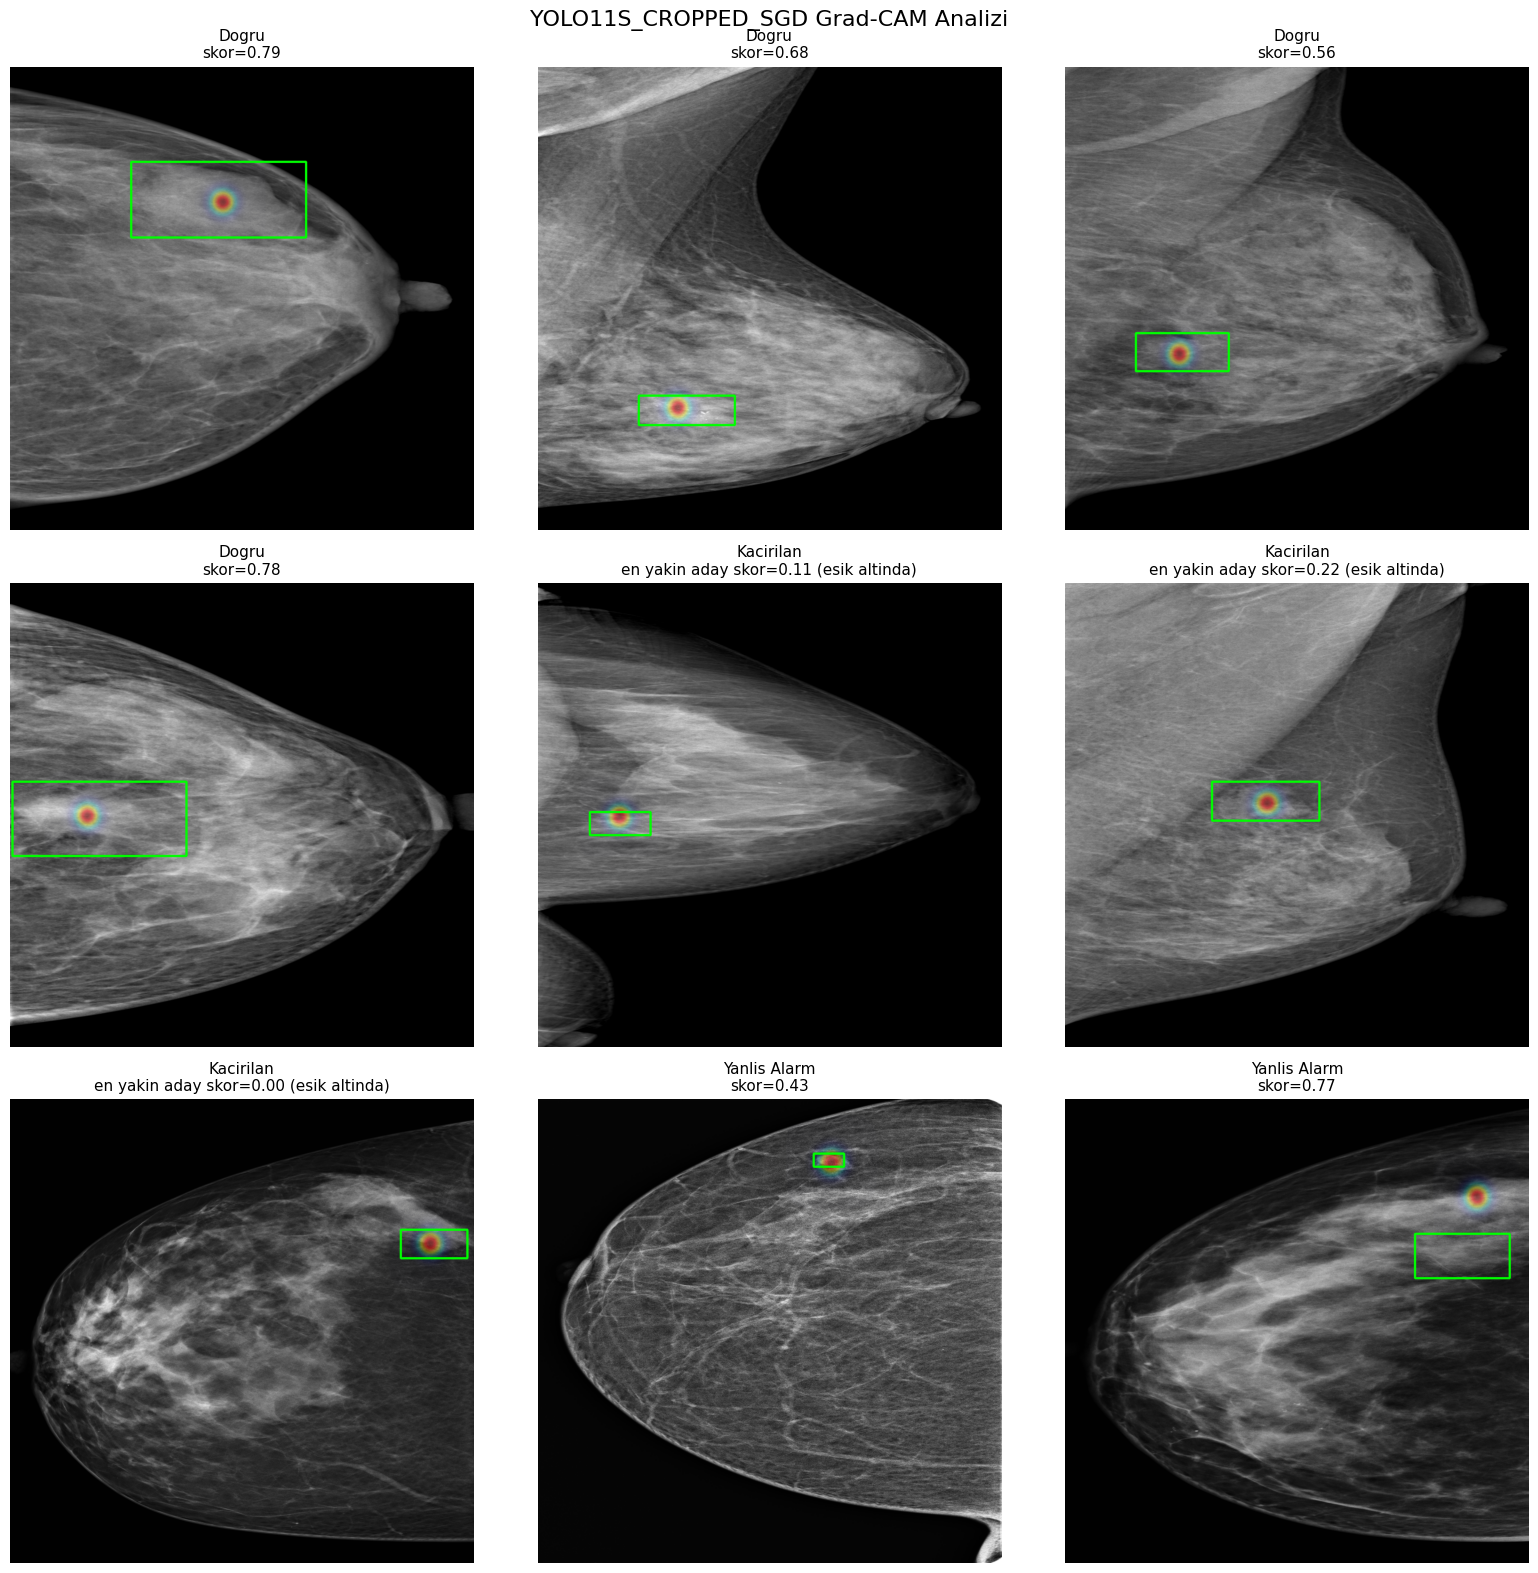

Kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/yolo11s_cropped_sgd/yolo11s_cropped_sgd_gradcam.png


In [33]:
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

gc_model_y11 = YOLO(YOLO11_CKPT)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tm_y11 = gc_model_y11.model.to(device)
tm_y11.eval()
for p in tm_y11.parameters():
    p.requires_grad_(True)

CAM_THRESH = 0.25
CAM_IMGSZ_Y11 = 1024

def categorize_y11(img_path):
    res = gc_model_y11.predict(str(img_path), imgsz=CAM_IMGSZ_Y11, conf=0.25, verbose=False)[0]
    preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()] if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)
    matched = set(); tp = 0
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= 0.5:
            tp += 1; matched.add(bj)
    fp = len(preds) - tp
    fn = len(gts) - len(matched)
    if tp > 0 and fp == 0 and fn == 0:
        return 'dogru'
    elif fp > 0 and tp == 0:
        return 'yanlis_alarm'
    elif fn > 0 and tp == 0:
        return 'kacirilan'
    return 'karisik'

def compute_overlay_y11(img_path):
    # Hedefli Grad-CAM: tespit/gercek kutu merkezindeki P3 hucresinden geri yay.
    #
    # NOT: dusuk esikli (conf=0.001) tek bir tarama kullaniyoruz, boylece
    # hem "gercek tespit" (>=0.25) hem de "esigin altinda kalan en yakin
    # aday" bilgisini ayni taramadan alabiliyoruz. Bu ikincisi onemli:
    # ısı haritasi her goruntude kendi icinde [0,1]'e normalize edildigi
    # icin, "Kacirilan" bir ornekte model o bolgeye zayifca bakmis olsa
    # bile (esigi gecmemis) harita gorsel olarak "Dogru" ornekler kadar
    # yogun/kirmizi cikabiliyor -- bu yaniltici olabiliyor. Panel
    # basligina gercek skoru eklemek bu belirsizligi gideriyor.
    res_all = gc_model_y11.predict(str(img_path), imgsz=CAM_IMGSZ_Y11, conf=0.001, verbose=False)[0]
    all_boxes = res_all.boxes.xywhn.cpu().numpy() if (res_all.boxes is not None and len(res_all.boxes) > 0) else np.zeros((0, 4))
    all_confs = res_all.boxes.conf.cpu().numpy() if (res_all.boxes is not None and len(res_all.boxes) > 0) else np.zeros((0,))
    det_mask = all_confs >= 0.25
    det_boxes = all_boxes[det_mask]
    det_confs = all_confs[det_mask]
    gts = load_gt(img_path.stem)

    if len(det_boxes) > 0:
        bx = det_boxes[det_confs.argmax()]
        target_cx, target_cy = float(bx[0]), float(bx[1])
        score_str = f'skor={det_confs.max():.2f}'
    elif len(gts) > 0:
        target_cx, target_cy = gts[0][0], gts[0][1]
        if len(all_boxes) > 0:
            ious = [iou_xywh(all_boxes[q], gts[0]) for q in range(len(all_boxes))]
            best_q = int(np.argmax(ious))
            score_str = f'en yakin aday skor={all_confs[best_q]:.2f} (esik altinda)'
        else:
            score_str = 'aday yok'
    else:
        target_cx, target_cy = 0.5, 0.5
        score_str = ''

    img_bgr = cv2.imread(str(img_path))
    img_r = cv2.resize(img_bgr, (CAM_IMGSZ_Y11, CAM_IMGSZ_Y11))
    x = torch.from_numpy(img_r[:, :, ::-1].copy()).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0).to(device)
    x.requires_grad_(True)

    cam_store = {}
    def cam_hook(m, i, o):
        o.retain_grad()
        cam_store['out'] = o
    h_cam = tm_y11.model[16].register_forward_hook(cam_hook)
    logit_store = {}
    def logit_hook(m, i, o):
        logit_store['out'] = o
    h_logit = tm_y11.model[-1].cv3[0].register_forward_hook(logit_hook)

    with torch.enable_grad():
        tm_y11.zero_grad()
        _ = tm_y11(x)
        logits = logit_store['out']
        _, nc, Hh, Ww = logits.shape
        gx = min(int(target_cx * Ww), Ww - 1)
        gy = min(int(target_cy * Hh), Hh - 1)
        target = logits[0, :, gy, gx].sum()
        target.backward()

    A = cam_store['out'].detach()
    G = cam_store['out'].grad
    h_cam.remove()
    h_logit.remove()

    # NOT: kanal agirligini gradyanin TUM haritadaki ortalamasi (GAP,
    # w = G.mean(dim=[2,3])) ile hesaplayip TUM aktivasyon haritasina
    # geri uygulamiyoruz. Bu, standart (siniflandirma-tarzi) Grad-CAM
    # formulu ama tekil bir tespit icin YANLIS: gradyan zaten hedef
    # hucrenin reseptif alanina yakin yerlerde yogunlasmis durumda
    # (bilgi tasiyor), GAP bu uzamsal bilgiyi atip "hedefle alakali kanal"
    # etiketini goruntudeki HER yere (mm. meme ucu, alakasiz parlak
    # dokular) yayiyor -- gozlemlenen "kutu bomboş, baska yerde izole
    # sicak noktalar" hatasinin kok nedeni buydu. Duzeltme: gradyani
    # ortalamadan, eleman-bazli Grad x Aktivasyon kullaniyoruz --
    # G kendisi zaten hedefe nedensel olarak baglı olmayan bolgelerde
    # sifira yakin, bu yuzden bu carpim dogal olarak lokalize kaliyor.
    cam = torch.relu((G * A).sum(dim=1)).squeeze().cpu().numpy()

    # kenar/dolgu (zero-padding) artefaktini bastir: konvolusyon dolgusu en
    # dis hucre halkasinda goruntu icerigiyle ilgisiz, yapay yuksek
    # aktivasyona yol acabiliyor -- bilinen bir Grad-CAM siniri.
    #
    # NOT: burada yuzdelik-dilim tabanli kirpma (RF-DETR'de kullanilan)
    # KASITLI OLARAK KULLANILMIYOR. RF-DETR'de sinyal yogun/isaretliydi
    # (ReLU yok), ama burada ReLU sonrasi harita cok seyrek (aktif
    # hucreler haritanin >%1'i degil) -- yuzdelik kirpma boyle seyrek bir
    # dizide neredeyse her zaman "0" degerine denk gelip haritayi tamamen
    # bosaltiyor (denendi, "Dogru" orneklerde bos harita ile sonuclandi).
    # Bu yuzden duz min-max normalize korunuyor.
    border = max(1, int(round(0.04 * min(cam.shape))))
    cam[:border, :] = 0
    cam[-border:, :] = 0
    cam[:, :border] = 0
    cam[:, -border:] = 0

    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    cam_r = cv2.resize(cam.astype('float32'), (CAM_IMGSZ_Y11, CAM_IMGSZ_Y11))
    cam_r = cv2.GaussianBlur(cam_r, (0, 0), sigmaX=20)
    if cam_r.max() > 0:
        cam_r = cam_r / cam_r.max()

    gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    tissue = (gray > 15).astype('float32')
    cam_r = cam_r * tissue

    # esikli "ada" gorunumu yerine surekli alfa-karisim: literaturdeki
    # standart Grad-CAM gosterimi (esik gercek dagilimi gizleyip yaniltici
    # izole noktalar yaratabiliyor, bkz. Kirchknopf vd. 2022 Fig. 2)
    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET).astype(np.float32)
    alpha = (0.55 * cam_r)[:, :, None]
    overlay = (img_r.astype(np.float32) * (1 - alpha) + hm * alpha).astype(np.uint8)

    for (cx, cy, bw, bh) in gts:
        x1 = int((cx - bw / 2) * CAM_IMGSZ_Y11); y1 = int((cy - bh / 2) * CAM_IMGSZ_Y11)
        x2 = int((cx + bw / 2) * CAM_IMGSZ_Y11); y2 = int((cy + bh / 2) * CAM_IMGSZ_Y11)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return overlay, score_str

all_imgs = sorted(TEST_IMG_DIR.glob('*.png'))
buckets = {'dogru': [], 'kacirilan': [], 'yanlis_alarm': [], 'karisik': []}
for ip in all_imgs[:120]:
    buckets[categorize_y11(ip)].append(ip)

selected_y11 = []
selected_y11 += [(p, 'Dogru') for p in buckets['dogru'][:4]]
selected_y11 += [(p, 'Kacirilan') for p in buckets['kacirilan'][:3]]
selected_y11 += [(p, 'Yanlis Alarm') for p in buckets['yanlis_alarm'][:2]]
while len(selected_y11) < 9 and buckets['karisik']:
    selected_y11.append((buckets['karisik'].pop(0), 'Karisik'))
selected_y11 = selected_y11[:9]

print(f'Secilen ornek (YOLO11s): {len(selected_y11)}')
for p, lab in selected_y11:
    print(f'  {lab}: {p.name}')

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, (ip, lab) in zip(axes.flat, selected_y11):
    ov, score_str = compute_overlay_y11(ip)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{lab}\n{score_str}', fontsize=11)
    ax.axis('off')
for ax in axes.flat[len(selected_y11):]:
    ax.axis('off')

plt.suptitle('YOLO11S_CROPPED_SGD Grad-CAM Analizi', fontsize=16)
plt.tight_layout()
gradcam_path = f"{OUT_DIRS['yolo11s_cropped_sgd']}/yolo11s_cropped_sgd_gradcam.png"
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
mirror_to_local(gradcam_path)
plt.show()
print('Kaydedildi (Drive + yerel):', gradcam_path)


## 2. YOLO26s Grad-CAM

YOLO26 NMS'siz (end2end) bir tespit başı kullanıyor: `cv2`/`cv3` yerine
`one2one_cv2`/`one2one_cv3` var. Ayrıca `one2one_cv3` dalı, paylaşılan P3
gövde özelliğinin ayrılmış (stop-gradient) bir kopyasını aldığı için
aktivasyon ve logit hook'larının **ikisi de** `one2one_cv3[0]` içinden
alınıyor (aksi hâlde gradyan gövdeye hiç ulaşmıyor) -- bu proje daha önce
teşhis edip düzelttiği bir mimari farkı.

Secilen ornek (YOLO26s): 9
  Dogru: 058e5f91678b4d3dac39bf1b6a798a22.png
  Dogru: 0734a9dc7d6d89e8c91458545afeef9d.png
  Dogru: 0d0826dc6e633a7729ea56fa7390c508.png
  Dogru: 0dc38f7b2936fff46ec10a0beb5aaeb2.png
  Kacirilan: 00be38a5c0566291168fe381ba0028e6.png
  Kacirilan: 02d253f51556e2e0af63525de2e9ff74.png
  Kacirilan: 032ab9e0ecd5fd673517ffa3eb805d15.png
  Yanlis Alarm: 0c19be554e27e2fdc2fe05ad954e825c.png
  Yanlis Alarm: 11041_RCC.png


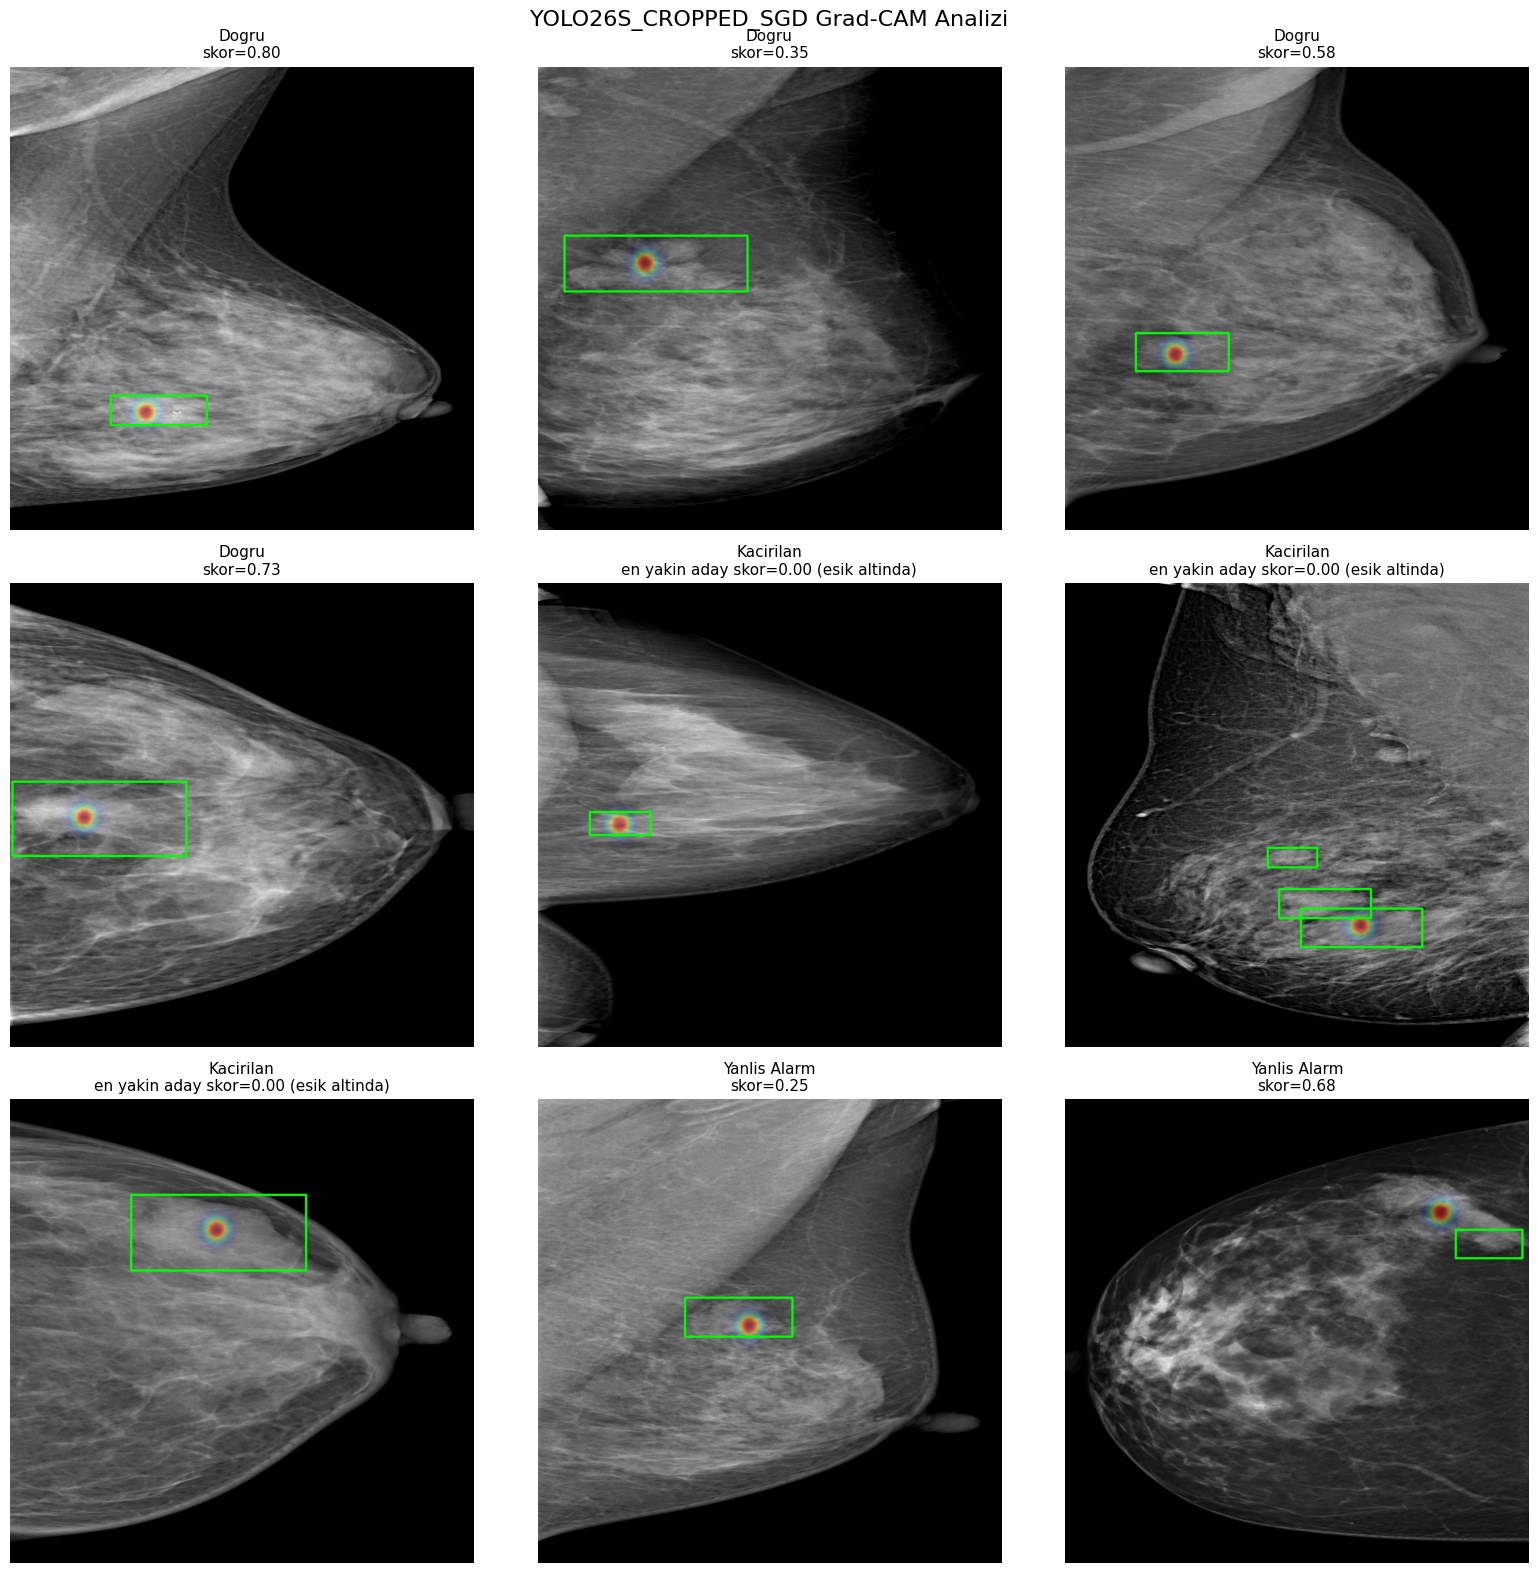

Kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_gradcam.png


In [34]:
gc_model_y26 = YOLO(YOLO26_CKPT)

# ayri, hic .predict() cagrilmamis model -- Ultralytics'in predict()'i
# torch.inference_mode() altinda calisiyor, bu da bazi ic tensorleri
# (anchor/stride onbellegi gibi) kalici olarak gradyan gerektiremez hale
# getirebiliyor. Iki modeli ayirmak bu "zehirlenmeyi" onluyor.
cam_model_y26 = YOLO(YOLO26_CKPT)
tm_y26 = cam_model_y26.model.to(device)
tm_y26.eval()
for p in tm_y26.parameters():
    p.requires_grad_(True)

CAM_IMGSZ_Y26 = 1024


def categorize_y26(img_path):
    res = gc_model_y26.predict(str(img_path), imgsz=CAM_IMGSZ_Y26, conf=0.25, verbose=False)[0]
    preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()] if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)
    matched = set(); tp = 0
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= 0.5:
            tp += 1; matched.add(bj)
    fp = len(preds) - tp
    fn = len(gts) - len(matched)
    if tp > 0 and fp == 0 and fn == 0:
        return 'dogru'
    elif fp > 0 and tp == 0:
        return 'yanlis_alarm'
    elif fn > 0 and tp == 0:
        return 'kacirilan'
    return 'karisik'


def compute_overlay_y26(img_path):
    # NOT: dusuk esikli (conf=0.001) tek bir tarama kullaniyoruz -- bkz.
    # YOLO11 hucresindeki gerekce (esik-alti "en yakin aday" skorunu da
    # gorebilmek, "Kacirilan" panellerin gorsel olarak "Dogru" ile
    # karistirilmasini onlemek icin).
    res_all = gc_model_y26.predict(str(img_path), imgsz=CAM_IMGSZ_Y26, conf=0.001, verbose=False)[0]
    all_boxes = res_all.boxes.xywhn.cpu().numpy() if (res_all.boxes is not None and len(res_all.boxes) > 0) else np.zeros((0, 4))
    all_confs = res_all.boxes.conf.cpu().numpy() if (res_all.boxes is not None and len(res_all.boxes) > 0) else np.zeros((0,))
    det_mask = all_confs >= 0.25
    det_boxes = all_boxes[det_mask]
    det_confs = all_confs[det_mask]
    gts = load_gt(img_path.stem)

    if len(det_boxes) > 0:
        bx = det_boxes[det_confs.argmax()]
        target_cx, target_cy = float(bx[0]), float(bx[1])
        score_str = f'skor={det_confs.max():.2f}'
    elif len(gts) > 0:
        target_cx, target_cy = gts[0][0], gts[0][1]
        if len(all_boxes) > 0:
            ious = [iou_xywh(all_boxes[q], gts[0]) for q in range(len(all_boxes))]
            best_q = int(np.argmax(ious))
            score_str = f'en yakin aday skor={all_confs[best_q]:.2f} (esik altinda)'
        else:
            score_str = 'aday yok'
    else:
        target_cx, target_cy = 0.5, 0.5
        score_str = ''

    img_bgr = cv2.imread(str(img_path))
    img_r = cv2.resize(img_bgr, (CAM_IMGSZ_Y26, CAM_IMGSZ_Y26))
    x = torch.from_numpy(img_r[:, :, ::-1].copy()).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0).to(device)
    x.requires_grad_(True)

    cls_branch = tm_y26.model[-1].one2one_cv3[0]

    cam_store = {}
    def cam_hook(m, i, o):
        o.retain_grad()
        cam_store['out'] = o
    h_cam = cls_branch[0].register_forward_hook(cam_hook)
    logit_store = {}
    def logit_hook(m, i, o):
        logit_store['out'] = o
    h_logit = cls_branch.register_forward_hook(logit_hook)

    with torch.enable_grad():
        tm_y26.zero_grad()
        _ = tm_y26(x)
        logits = logit_store['out']
        _, nc, Hh, Ww = logits.shape
        gx = min(int(target_cx * Ww), Ww - 1)
        gy = min(int(target_cy * Hh), Hh - 1)
        target = logits[0, :, gy, gx].sum()
        target.backward()

    A = cam_store['out'].detach()
    G = cam_store['out'].grad
    h_cam.remove()
    h_logit.remove()

    # NOT: eleman-bazli Grad x Aktivasyon kullaniliyor, GAP (w=G.mean(...))
    # DEGIL -- bkz. YOLO11 hucresindeki gerekce (GAP, hedefle alakali
    # kanallarin goruntudeki BASKA yerlerdeki aktivasyonlarini da
    # yayiyordu; kutu bomboş, baska yerde izole sicak noktalar hatasinin
    # kok nedeni buydu).
    cam = torch.relu((G * A).sum(dim=1)).squeeze().cpu().numpy()

    # kenar/dolgu (zero-padding) artefaktini bastir -- bkz. YOLO11 hucresindeki not.
    # NOT: yuzdelik-dilim kirpma burada da KASITLI OLARAK KULLANILMIYOR --
    # bkz. YOLO11 hucresindeki gerekce (ReLU sonrasi seyrek harita,
    # yuzdelik kirpma bos harita uretiyor).
    border = max(1, int(round(0.04 * min(cam.shape))))
    cam[:border, :] = 0
    cam[-border:, :] = 0
    cam[:, :border] = 0
    cam[:, -border:] = 0

    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    cam_r = cv2.resize(cam.astype('float32'), (CAM_IMGSZ_Y26, CAM_IMGSZ_Y26))
    cam_r = cv2.GaussianBlur(cam_r, (0, 0), sigmaX=20)
    if cam_r.max() > 0:
        cam_r = cam_r / cam_r.max()

    gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    tissue = (gray > 15).astype('float32')
    cam_r = cam_r * tissue

    # esikli "ada" gorunumu yerine surekli alfa-karisim -- bkz. YOLO11 hucresindeki not
    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET).astype(np.float32)
    alpha = (0.55 * cam_r)[:, :, None]
    overlay = (img_r.astype(np.float32) * (1 - alpha) + hm * alpha).astype(np.uint8)

    for (cx, cy, bw, bh) in gts:
        x1 = int((cx - bw / 2) * CAM_IMGSZ_Y26); y1 = int((cy - bh / 2) * CAM_IMGSZ_Y26)
        x2 = int((cx + bw / 2) * CAM_IMGSZ_Y26); y2 = int((cy + bh / 2) * CAM_IMGSZ_Y26)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return overlay, score_str


buckets = {'dogru': [], 'kacirilan': [], 'yanlis_alarm': [], 'karisik': []}
for ip in all_imgs[:120]:
    buckets[categorize_y26(ip)].append(ip)

selected_y26 = []
selected_y26 += [(p, 'Dogru') for p in buckets['dogru'][:4]]
selected_y26 += [(p, 'Kacirilan') for p in buckets['kacirilan'][:3]]
selected_y26 += [(p, 'Yanlis Alarm') for p in buckets['yanlis_alarm'][:2]]
while len(selected_y26) < 9 and buckets['karisik']:
    selected_y26.append((buckets['karisik'].pop(0), 'Karisik'))
selected_y26 = selected_y26[:9]

print(f'Secilen ornek (YOLO26s): {len(selected_y26)}')
for p, lab in selected_y26:
    print(f'  {lab}: {p.name}')

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, (ip, lab) in zip(axes.flat, selected_y26):
    ov, score_str = compute_overlay_y26(ip)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{lab}\n{score_str}', fontsize=11)
    ax.axis('off')
for ax in axes.flat[len(selected_y26):]:
    ax.axis('off')

plt.suptitle('YOLO26S_CROPPED_SGD Grad-CAM Analizi', fontsize=16)
plt.tight_layout()
gradcam_path = f"{OUT_DIRS['yolo26s_cropped_sgd']}/yolo26s_cropped_sgd_gradcam.png"
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
mirror_to_local(gradcam_path)
plt.show()
print('Kaydedildi (Drive + yerel):', gradcam_path)


## 3. RF-DETR-S Grad-CAM

RF-DETR'nin mimarisi YOLO'dan tamamen farklı (DINOv2 transformer omurga +
DETR-tarzı sorgu tabanlı dedektör başı). Kaynak koddan
(`github.com/roboflow/rf-detr`, `src/rfdetr/models/lwdetr.py` ve
`backbone/__init__.py`) doğrulanan yapı:

- `rfdetr_wrapper.model.model` -- gerçek `nn.Module` (`LWDETR` sınıfı)
- `lwdetr.backbone` -- bir `Joiner` (`nn.Sequential`): `forward()` çağrıldığında
  `(features, pos_embeddings, cross_attn_features)` döndürür; `features` çok
  ölçekli `NestedTensor` listesi, her biri `.tensors` ile `(B, C, H, W)`
  şeklinde düz bir tensöre erişim sağlıyor.
- `lwdetr.class_embed` -- düz bir `nn.Linear(hidden_dim, num_classes)`,
  transformer decoder'ın sorgu-başına gizli durumuna (`hs`) uygulanıyor.
- Ham modeli doğrudan çağırmak (`lwdetr(batch_tensor)`) bir `(pred_boxes,
  pred_logits)` tuple'ı döndürüyor; `pred_boxes` normalize edilmiş
  `(cx, cy, w, h)` formatında -- YOLO'nunkiyle **aynı format**, bu yüzden
  aynı `iou_xywh` fonksiyonu doğrudan kullanılabiliyor.
- Ön işleme (`predict()` metodundan): `to_tensor` (0-1 aralığı) →
  `resize` (`antialias=False`, modelin çözünürlüğüne) → `normalize`
  (`wrapper.means`, `wrapper.stds`).

Bu bilgiler kurulu paket sürümünde birebir doğru olmayabilir -- bu yüzden
önce bir teşhis hücresi çalıştırılıp varsayımlar doğrulanıyor.

In [35]:
from rfdetr import RFDETRSmall

rf_wrapper = RFDETRSmall(pretrain_weights=RFDETR_CKPT)
rf_model = rf_wrapper.model.model  # kaynaktan dogrulanan LWDETR nn.Module
rf_model.to(device)
rf_model.eval()

print('Model tipi:', type(rf_model))
print('backbone var mi:', hasattr(rf_model, 'backbone'))
print('class_embed var mi:', hasattr(rf_model, 'class_embed'), '->', rf_model.class_embed if hasattr(rf_model, 'class_embed') else None)
print('wrapper.means:', rf_wrapper.means)
print('wrapper.stds:', rf_wrapper.stds)
print('model.resolution:', rf_wrapper.model.resolution)

# kucuk bir sahte girdiyle ileri gecis yapip gercek sekilleri dogrula.
# NOT: rf_model.backbone(...) dogrudan cagrilirsa duz bir tensor yerine
# NestedTensor bekler (AttributeError verir) -- bu yuzden backbone'u
# gercek Grad-CAM hucresindeki gibi bir forward-hook ile, ust seviye
# rf_model(...) cagrisi icinden gozlemliyoruz; gercekte kullanilacak yol
# budur.
_dummy = torch.zeros(1, 3, rf_wrapper.model.resolution, rf_wrapper.model.resolution, device=device)

_diag = {}
def _diag_hook(m, i, o):
    _diag['backbone_out'] = o
_h = rf_model.backbone.register_forward_hook(_diag_hook)

with torch.no_grad():
    _out = rf_model(_dummy)

_h.remove()

print('\nModel cikti tipi:', type(_out))
if isinstance(_out, dict):
    print('dict anahtarlari:', list(_out.keys()))
    for k, v in _out.items():
        print(f'  {k} sekli:', v.shape if hasattr(v, 'shape') else type(v))
elif isinstance(_out, (tuple, list)):
    for i, o in enumerate(_out):
        print(f'  cikti[{i}] sekli:', o.shape if hasattr(o, 'shape') else type(o))

_feats = _diag['backbone_out'][0]
print('\nbackbone forward-hook cikti uzunlugu:', len(_diag['backbone_out']))
print('features listesi uzunlugu:', len(_feats))
for i, f in enumerate(_feats):
    t = f.tensors if hasattr(f, 'tensors') else f
    print(f'  features[{i}].tensors sekli:', t.shape)

print('\nBeklenen: dict ise "pred_boxes" [1,num_sorgu,4] ve "pred_logits" [1,num_sorgu,C],')
print('features[i].tensors [1,C,H,W]. Farkli gorunuyorsa bir sonraki hucredeki')
print('ilgili anahtar/indeksleri buradaki gercek sekillere gore duzeltin.')


[2026-07-21 11:15:37] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-21 11:15:37] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-21 11:15:38] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-07-21 11:15:38] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


Model tipi: <class 'rfdetr.models.lwdetr.LWDETR'>
backbone var mi: True
class_embed var mi: True -> Linear(in_features=256, out_features=2, bias=True)
wrapper.means: [0.485, 0.456, 0.406]
wrapper.stds: [0.229, 0.224, 0.225]
model.resolution: 512

Model cikti tipi: <class 'dict'>
dict anahtarlari: ['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs']
  pred_logits sekli: torch.Size([1, 300, 2])
  pred_boxes sekli: torch.Size([1, 300, 4])
  aux_outputs sekli: <class 'list'>
  enc_outputs sekli: <class 'dict'>

backbone forward-hook cikti uzunlugu: 3
features listesi uzunlugu: 1
  features[0].tensors sekli: torch.Size([1, 256, 32, 32])

Beklenen: dict ise "pred_boxes" [1,num_sorgu,4] ve "pred_logits" [1,num_sorgu,C],
features[i].tensors [1,C,H,W]. Farkli gorunuyorsa bir sonraki hucredeki
ilgili anahtar/indeksleri buradaki gercek sekillere gore duzeltin.


Secilen ornek (RF-DETR-S): 9
  Dogru: 032ab9e0ecd5fd673517ffa3eb805d15.png
  Dogru: 058e5f91678b4d3dac39bf1b6a798a22.png
  Dogru: 0c19be554e27e2fdc2fe05ad954e825c.png
  Dogru: 0d0826dc6e633a7729ea56fa7390c508.png
  Yanlis Alarm: 00be38a5c0566291168fe381ba0028e6.png
  Yanlis Alarm: 11041_RCC.png
  Karisik: 02d253f51556e2e0af63525de2e9ff74.png
  Karisik: 0734a9dc7d6d89e8c91458545afeef9d.png
  Karisik: 0b597a53d015b5d2c2df81f4c19eeea0.png


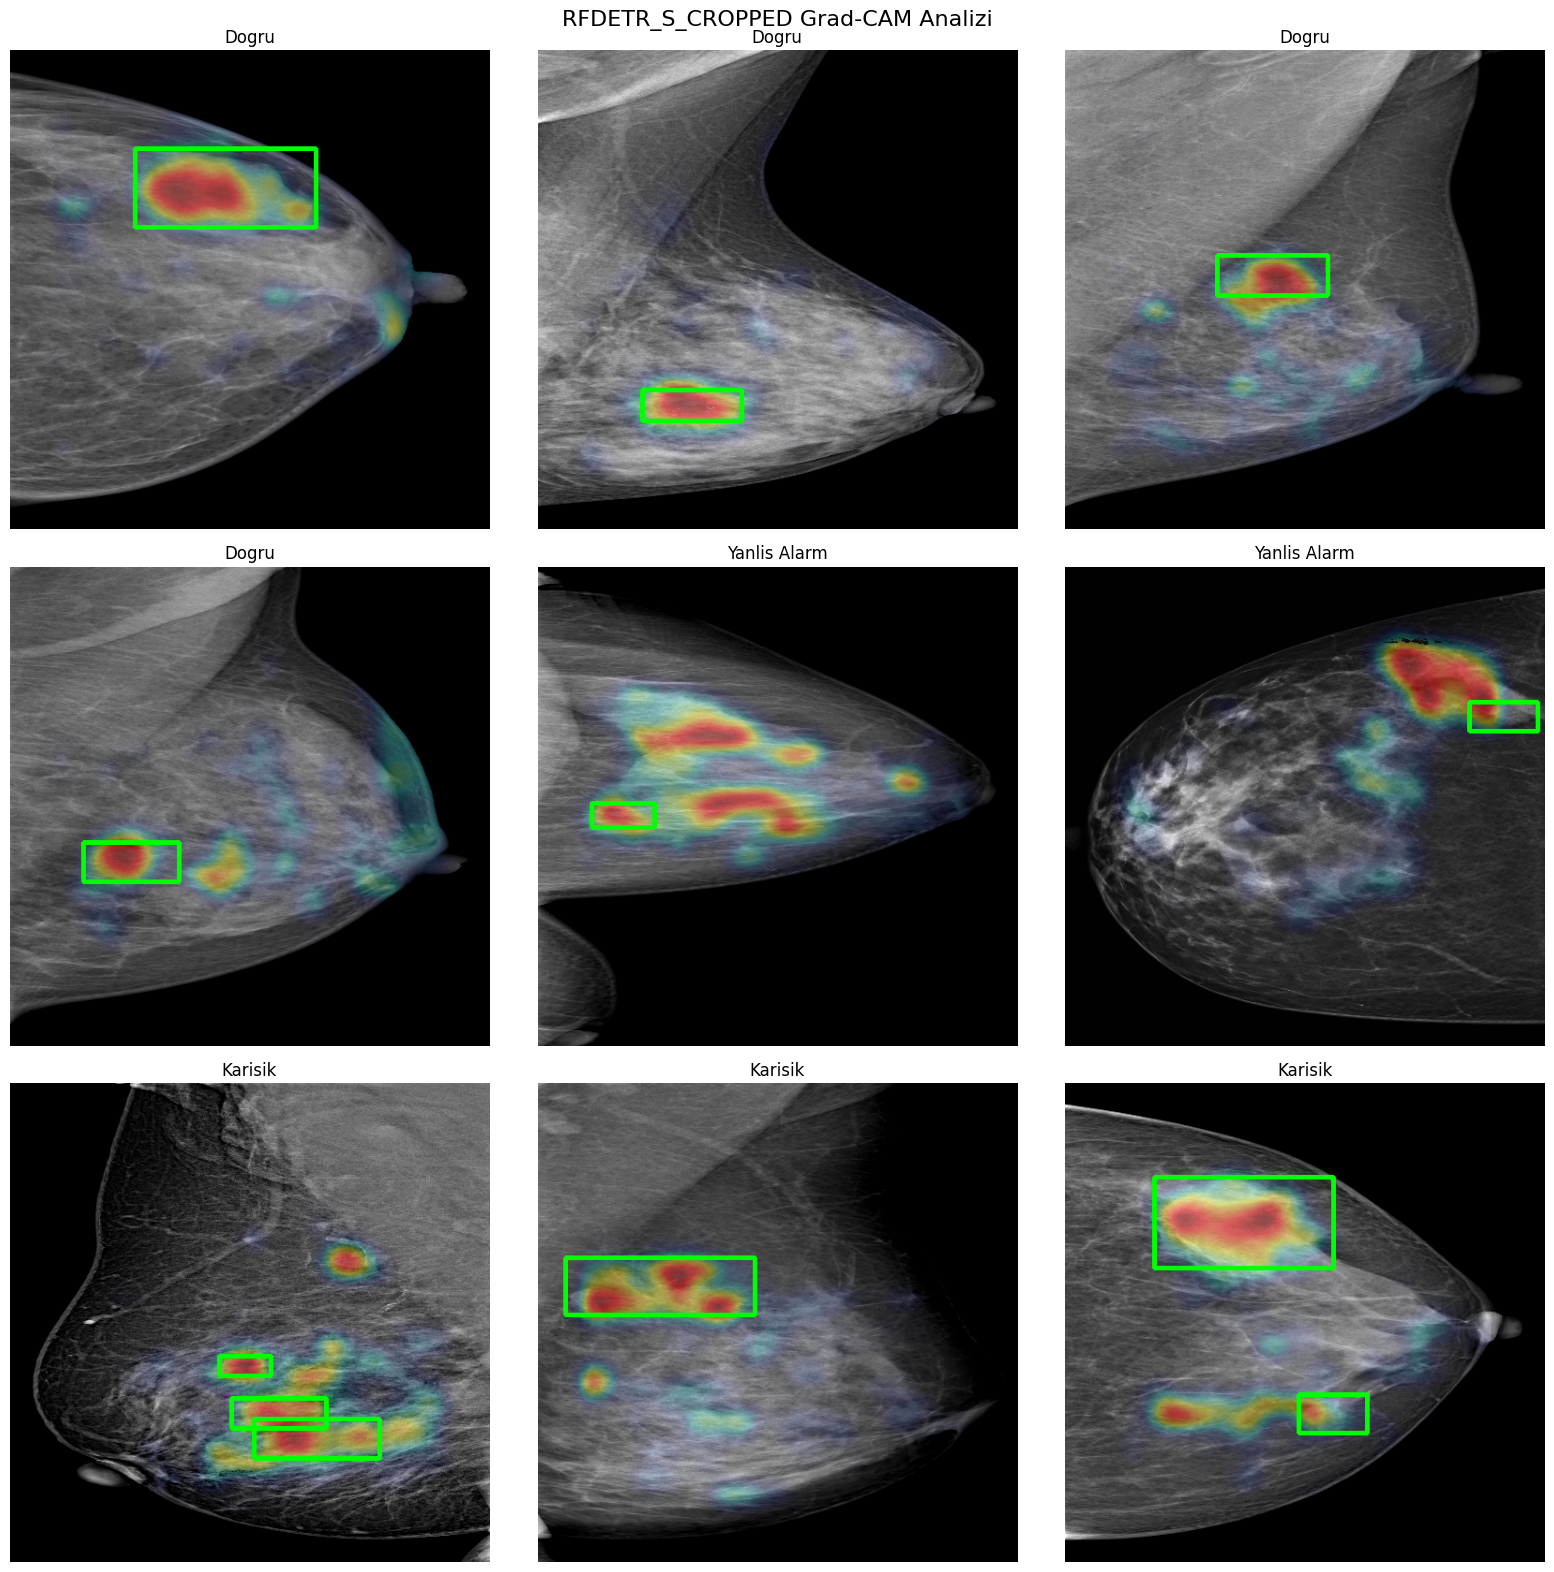

Kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_gradcam.png


In [36]:
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF

RF_RES = rf_wrapper.model.resolution
RF_MEANS = rf_wrapper.means
RF_STDS = rf_wrapper.stds
# tek sinif (mass) icin egitildi; class_embed 2 cikis veriyor (teshis
# hucresinde goruldu) -- ikinci indeks muhtemelen "nesne yok" / arka plan
# slotu (DETR-tarzi modellerde yaygin bir kalip). Indeks 0 = mass.
RF_CLASS_IDX = 0

RF_DEBUG = False


def rf_preprocess(img_path):
    # predict() ile birebir ayni on isleme: to_tensor -> resize(antialias=False) -> normalize
    pil_img = Image.open(img_path).convert('RGB')
    t = TF.to_tensor(pil_img)
    t = TF.resize(t, [RF_RES, RF_RES], antialias=False)
    t_norm = TF.normalize(t, RF_MEANS, RF_STDS)
    return t, t_norm  # t: 0-1 gorsellestirme icin, t_norm: model girdisi


def rf_forward(img_path):
    t, t_norm = rf_preprocess(img_path)
    x = t_norm.unsqueeze(0).to(device)

    cam_store = {}
    def backbone_hook(m, i, o):
        feats = o[0]
        feat_tensor = feats[0].tensors  # en ince olcek, (1, C, H, W)
        feat_tensor.retain_grad()
        cam_store['feat'] = feat_tensor
    h_bb = rf_model.backbone.register_forward_hook(backbone_hook)

    with torch.enable_grad():
        rf_model.zero_grad()
        out = rf_model(x)
        # ham model dict donduruyor (teshis hucresinde dogrulandi) --
        # export/optimize edilmis model tuple dondurebilir, ikisini de
        # destekle
        if isinstance(out, dict):
            pred_boxes, pred_logits = out['pred_boxes'], out['pred_logits']
        else:
            pred_boxes, pred_logits = out[0], out[1]

    h_bb.remove()
    return t, pred_boxes, pred_logits, cam_store


def categorize_rf(img_path):
    _, pred_boxes, pred_logits, _ = rf_forward(img_path)
    scores = pred_logits[0, :, RF_CLASS_IDX].detach().sigmoid().cpu().numpy()
    boxes_np = pred_boxes[0].detach().cpu().numpy()
    preds = [list(boxes_np[q]) for q in range(len(boxes_np)) if scores[q] >= 0.25]
    gts = load_gt(img_path.stem)
    matched = set(); tp = 0
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= 0.5:
            tp += 1; matched.add(bj)
    fp = len(preds) - tp
    fn = len(gts) - len(matched)
    if tp > 0 and fp == 0 and fn == 0:
        return 'dogru'
    elif fp > 0 and tp == 0:
        return 'yanlis_alarm'
    elif fn > 0 and tp == 0:
        return 'kacirilan'
    return 'karisik'


def compute_overlay_rf(img_path):
    t, pred_boxes, pred_logits, cam_store = rf_forward(img_path)
    scores = pred_logits[0, :, RF_CLASS_IDX].detach().sigmoid().cpu().numpy()
    boxes_np = pred_boxes[0].detach().cpu().numpy()
    gts = load_gt(img_path.stem)

    # hedef sorgu: en guvenli tespit (>=0.25) varsa o; yoksa (kacirilan durum)
    # gercek kutuya en yakin (en yuksek IoU) sorgu -- YOLO tarafindaki
    # "tespit varsa onu, yoksa gercek kutu merkezini kullan" mantiginin
    # sorgu-tabanli DETR karsiligi.
    conf_idxs = np.where(scores >= 0.25)[0]
    if len(conf_idxs) > 0:
        target_q = int(conf_idxs[scores[conf_idxs].argmax()])
    elif gts:
        ious = [iou_xywh(boxes_np[q], gts[0]) for q in range(len(boxes_np))]
        target_q = int(np.argmax(ious))
    else:
        target_q = int(scores.argmax())

    # bu ileri gecis zaten cam_store'u doldurdu (rf_forward icinde), simdi geri yay
    logit = pred_logits[0, target_q, RF_CLASS_IDX]
    logit.backward()

    A = cam_store['feat'].detach()
    G = cam_store['feat'].grad
    w = G.mean(dim=[2, 3], keepdim=True)

    # NOT: ReLU(sum(w*A)) UYGULANMIYOR -- teshis (RF_DEBUG) gosterdi ki
    # yuksek guvenli orneklerde bu harita her yerde negatif cikip ReLU'yu
    # tamamen sifirliyordu (DINOv2/ViT omurgasi LayerNorm kullaniyor,
    # BatchNorm+ReLU CNN'leri icin tasarlanan "ReLU sonrasi pozitif =
    # onemli" varsayimi burada gecerli degil).
    cam = (w * A).sum(dim=1).squeeze().cpu().numpy()

    if RF_DEBUG:
        print(
            f'    [RF_DEBUG] {img_path.name}: skor={scores[target_q]:.3f} '
            f'logit={logit.item():.3f} |G|_ort={G.abs().mean().item():.3e} '
            f'cam[min,max]=[{cam.min():.3e},{cam.max():.3e}]'
        )

    # kenar bolgesini (RF-DETR'nin 32x32 ozellik haritasinda ~3 hucre)
    # ISTATISTIKTEN HARIC tutuyoruz (henuz sifirlamiyoruz!). Bir onceki
    # denemede kenari erken sifirlamak, "Dogru" orneklerde (ham sinyal
    # neredeyse her yerde negatif) yapay "0" degerinin en yuksek
    # yuzdelik dilime girip gercek ic bolgeyi bastirmasina yol acti --
    # butun harita bosaldi. Bu yuzden yuzdelik istatistigi SADECE ic
    # bolgeden hesaplaniyor, kenar bastirma normalize ettikten SONRA
    # ayri bir carpimsal maske olarak uygulaniyor.
    border = max(2, int(round(0.10 * min(cam.shape))))
    interior = np.ones_like(cam, dtype=bool)
    interior[:border, :] = False
    interior[-border:, :] = False
    interior[:, :border] = False
    interior[:, -border:] = False

    # NOT: ReLU'suz isaretli harita, DINOv2'nin global self-attention'i
    # yuzunden neredeyse tum goruntude yumusak/genis-olcekli bir sinyal
    # tasiyor -- duz min-max normalize edilirse tum goruntu boyaniyor,
    # hicbir bolge one cikmiyor. Bunun yerine yuzdelik-dilim tabanli
    # kirpma kullaniliyor: sadece en guclu ~%25'lik dilim (70.-99.
    # yuzdelikler arasi, ic bolgeye gore) kontrasta sahip oluyor, geri
    # kalani bastiriliyor.
    lo, hi = np.percentile(cam[interior], [70, 99])
    cam = np.clip(cam, lo, hi)
    if hi > lo:
        cam = (cam - lo) / (hi - lo)
    else:
        cam = np.zeros_like(cam)

    # simdi kenari sifirla (normalize edilmis [0,1] haritada, istatistigi bozmadan)
    cam[~interior] = 0

    img_r = (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)  # RGB, (RF_RES,RF_RES,3)
    img_bgr = cv2.cvtColor(img_r, cv2.COLOR_RGB2BGR)

    cam_r = cv2.resize(cam.astype('float32'), (RF_RES, RF_RES))
    cam_r = cv2.GaussianBlur(cam_r, (0, 0), sigmaX=8)
    if cam_r.max() > 0:
        cam_r = cam_r / cam_r.max()

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    tissue = (gray > 15).astype('float32')
    cam_r = cam_r * tissue

    # esikli "ada" gorunumu yerine surekli alfa-karisim -- bkz. YOLO11 hucresindeki not
    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET).astype(np.float32)
    alpha = (0.55 * cam_r)[:, :, None]
    overlay = (img_bgr.astype(np.float32) * (1 - alpha) + hm * alpha).astype(np.uint8)

    for (cx, cy, bw, bh) in gts:
        x1 = int((cx - bw / 2) * RF_RES); y1 = int((cy - bh / 2) * RF_RES)
        x2 = int((cx + bw / 2) * RF_RES); y2 = int((cy + bh / 2) * RF_RES)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return overlay


buckets = {'dogru': [], 'kacirilan': [], 'yanlis_alarm': [], 'karisik': []}
for ip in all_imgs[:120]:
    buckets[categorize_rf(ip)].append(ip)

selected_rf = []
selected_rf += [(p, 'Dogru') for p in buckets['dogru'][:4]]
selected_rf += [(p, 'Kacirilan') for p in buckets['kacirilan'][:3]]
selected_rf += [(p, 'Yanlis Alarm') for p in buckets['yanlis_alarm'][:2]]
while len(selected_rf) < 9 and buckets['karisik']:
    selected_rf.append((buckets['karisik'].pop(0), 'Karisik'))
selected_rf = selected_rf[:9]

print(f'Secilen ornek (RF-DETR-S): {len(selected_rf)}')
for p, lab in selected_rf:
    print(f'  {lab}: {p.name}')

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, (ip, lab) in zip(axes.flat, selected_rf):
    ov = compute_overlay_rf(ip)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(lab, fontsize=12)
    ax.axis('off')
for ax in axes.flat[len(selected_rf):]:
    ax.axis('off')

plt.suptitle('RFDETR_S_CROPPED Grad-CAM Analizi', fontsize=16)
plt.tight_layout()
gradcam_path = f"{OUT_DIRS['rfdetr_s_cropped']}/rfdetr_s_cropped_gradcam.png"
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
mirror_to_local(gradcam_path)
plt.show()
print('Kaydedildi (Drive + yerel):', gradcam_path)


## Özet

Üç model de aynı stil kullanılarak (JET renk haritası, doku maskesi,
gerçek kutu yeşil çerçeve, Doğru/Kaçırılan/Yanlış Alarm etiketleri) test
setinden 9'ar örnek üzerinde görselleştirildi. Çıktılar:

- `mass_detection/yolo11s_cropped_sgd/yolo11s_cropped_sgd_gradcam.png`
- `mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_gradcam.png`
- `mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_gradcam.png`

YOLO11/YOLO26 için kullanılan yöntem (Kirchknopf vd., 2022) ile RF-DETR
için kullanılan yöntem, temel Grad-CAM formülünde aynı: bir tespitin sınıf
logit'inden seçilen bir konvolüsyonel/uzamsal özellik haritasına gradyan
geri yayılıyor, kanal bazında ağırlıklandırılıp üst-örnekleme uygulanıyor.
Hedef katman mimariye göre farklı (YOLO'da P3 gövde katmanı, RF-DETR'de
DINOv2 omurgasının çıktısı). **Normalizasyon adımı ise farklı:**
YOLO11/YOLO26'da standart ReLU + min-max kullanılıyor (BatchNorm+ReLU
CNN'leri için literatürdeki varsayımlarla tutarlı); RF-DETR'de bu
varsayım geçerli olmadığından (LayerNorm'lu ViT omurga, ağırlıklı harita
yüksek güvenli tespitlerde her yerde negatif çıkıyor) ReLU atlanıp
yüzdelik-dilim tabanlı kırpma (70.-99. yüzdelik, iç bölgeden hesaplanan)
kullanılıyor -- bu farkın nedeni ve teşhis süreci en üstteki hücrede
ayrıntılı anlatılıyor.
